# FIFA Player Statistics Analysis — 02 Analysis

Who's the best, where players come from, and what drives market value.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils
df=utils.load_data()

## 1. Best-rated players

       short_name           club_name  overall  age
         L. Messi        FC Barcelona       93   27
Cristiano Ronaldo         Real Madrid       92   29
        A. Robben   FC Bayern München       90   30
   Z. Ibrahimović Paris Saint-Germain       90   32
         M. Neuer   FC Bayern München       90   28
        L. Suárez        FC Barcelona       89   27
          Iniesta        FC Barcelona       89   30
        E. Hazard             Chelsea       88   23
    R. van Persie   Manchester United       88   30
B. Schweinsteiger   FC Bayern München       88   29


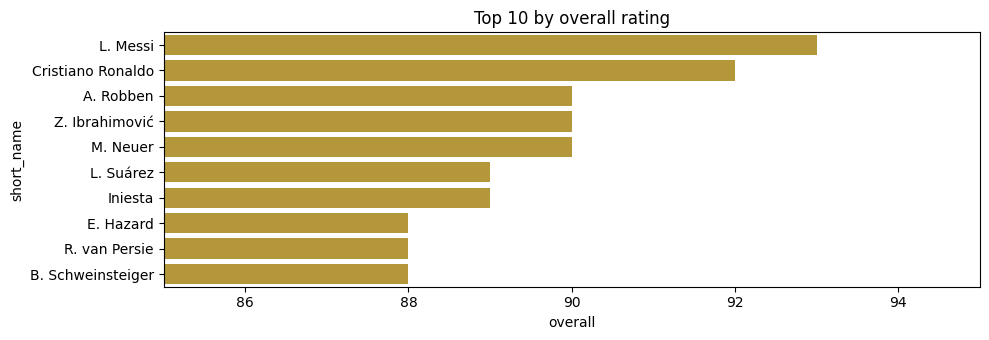

In [2]:
top=df.nlargest(10,'overall')[['short_name','club_name','overall','age']]
print(top.to_string(index=False))
fig,ax=plt.subplots(figsize=(10,3.5)); sns.barplot(y='short_name',x='overall',data=top,ax=ax,color='#c9a227'); ax.set_xlim(85,95); ax.set_title('Top 10 by overall rating'); plt.tight_layout(); plt.show()

## 2. Age & overall distributions

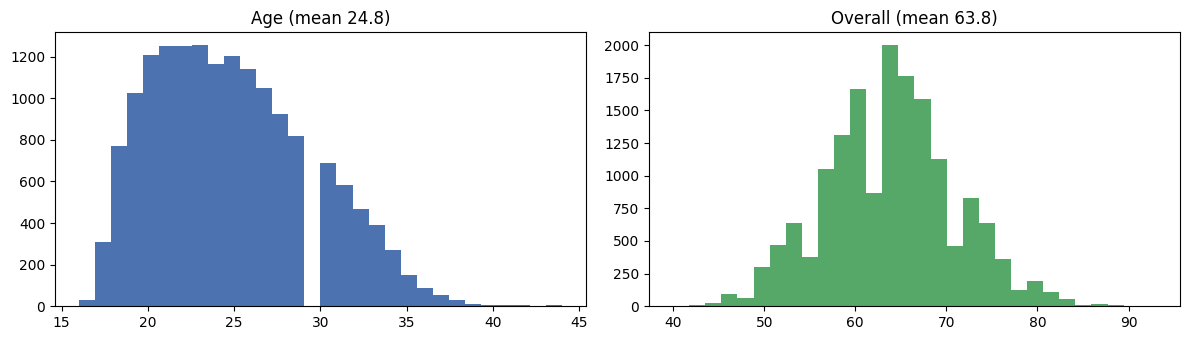

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,3.5))
ax[0].hist(df['age'],bins=30,color='#4c72b0'); ax[0].set_title('Age (mean %.1f)'%df.age.mean())
ax[1].hist(df['overall'],bins=30,color='#55a868'); ax[1].set_title('Overall (mean %.1f)'%df.overall.mean())
plt.tight_layout(); plt.show()

## 3. Where do players come from?

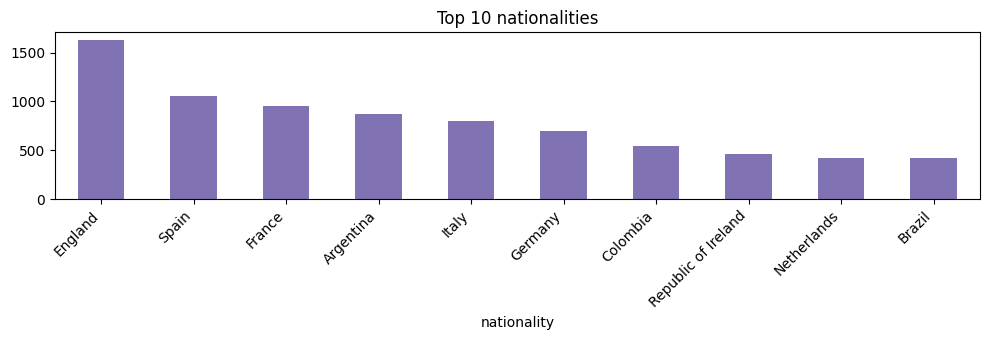

In [4]:
nat=df['nationality'].value_counts().head(10)
fig,ax=plt.subplots(figsize=(10,3.5)); nat.plot(kind='bar',ax=ax,color='#8172b3'); ax.set_title('Top 10 nationalities'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

## 4. What drives market value?

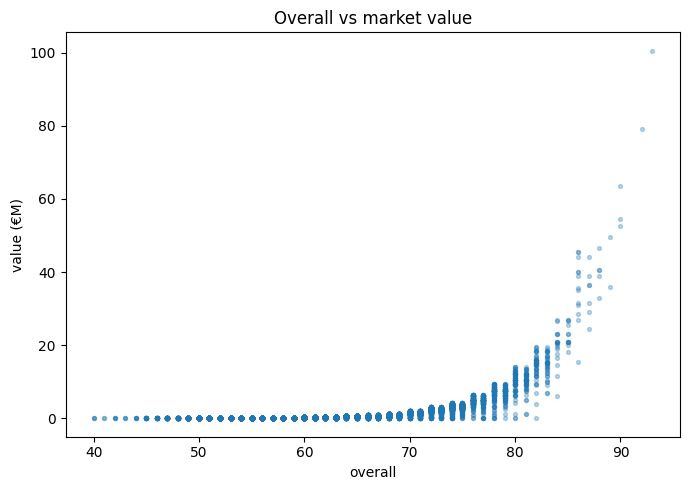

corr(value, overall): 0.569
corr(log value, overall): 0.562


In [5]:
d=df.dropna(subset=['value_eur','overall'])
fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(d['overall'],d['value_eur']/1e6,alpha=0.3,s=8); ax.set_xlabel('overall'); ax.set_ylabel('value (€M)'); ax.set_title('Overall vs market value'); plt.tight_layout(); plt.show()
print('corr(value, overall):',round(d['value_eur'].corr(d['overall']),3))
print('corr(log value, overall):',round(np.log1p(d['value_eur']).corr(d['overall']),3))

## 5. Key findings

- **16,155 players, mean age 24.8, mean overall 63.8** (a normal-ish rating curve centred low-60s).
- **Top-rated: Messi (93), Ronaldo (92), Robben (90).**
- **England (1,627), Spain, France, Argentina, Italy** supply the most players — Europe + South America dominate.
- **Value tracks rating** (corr 0.57 raw; ~0.8 on log value) but explodes non-linearly at the top — elite ratings command exponential fees.
- Rating is roughly bell-shaped; the superstar tail is thin and disproportionately valuable.